# EDA 05: Gene Fusions

## Purpose

`5_OmicsFusionFilteredSupplementary.csv` is an **event table**, not a matrix — one row per detected
gene-fusion event, not one row per (gene, cell line). A fusion joins two genes together at the DNA
level; a handful of specific fusions define entire cancer types (BCR-ABL1 in CML, EML4-ALK in
lung). Per `scratchpad/kausty/v5/PLAN.md` §4, fusion is being **promoted into the score** as a
scored layer (not just reported context) — this notebook is the evidence base for that promotion.

**Source, release, grain:** DepMap fusion calls, filtered. Event table, keyed by `ModelID` and
`SequencingID`. ~1,699 cell lines carry at least one fusion call.

## Questions this notebook must answer

1. Is the grain really one row per fusion event, and does `IsDefaultEntryForModel` need filtering
   first (multiple sequencing runs per line)?
2. What is the distribution of fusion burden per cell line?
3. Are the *most frequent* fusions the *biologically important* ones, or mostly artefacts?
4. What do confidence, structural type, and reading frame tell us about which calls are trustworthy?
5. What is the identity join path to the primary spine, and how much is lost?
6. Is fusion coverage lineage-biased?

**Interpretation rule:** a fusion event present in this table for a given cell line is `measured`.
The *absence* of a fusion event for a cell line that **is** in this table (i.e., it was sequenced
but no fusion involving the query gene was called) is `measured_absent` — a real "no fusion found"
result. A cell line that never appears in this table at all is `not_assayed` for fusions — and per
`scratchpad/kausty/v5/PLAN.md` §5, the correct user-facing string for that is **"fusion status
unknown"**, never "no fusion", since only ~1,699 of the catalogue were ever fusion-assayed.

## Column dictionary

| Column | Meaning | Notes |
|---|---|---|
| `ModelID` | DepMap identity key | direct 1:1 to file 9 |
| `SequencingID` | one sequencing run | a line can have >1; filter `IsDefaultEntryForModel=='Yes'` |
| `gene1(ENS ID)`, `gene2(ENS ID)` | fusion partner genes | Ensembl ID embedded in a packed string — regex-extract |
| `CanonicalFusionName` | e.g. `BCR--ABL1` | the two gene symbols joined by `--` |
| `confidence` | caller's confidence (high/medium/low) | |
| `type` | structural class of the fusion | |
| `reading_frame` | in-frame / out-of-frame / unknown | in-frame fusions are more likely to produce a functional fusion protein |
| `FFPM` | fusion fragments per million reads | expression strength of the fusion transcript; very low values may be noise |

## 1. Basic data contract and default-entry filtering

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
GENE_PROPERTIES = ROOT / 'data' / 'raw' / 'gene_properties'
NOMENCLATURE = ROOT / 'data' / 'raw' / 'nomenclature'
NON_GENE_EXPRESSION = ROOT / 'data' / 'raw' / 'non_gene_expression'

In [2]:
df = pd.read_csv(GENE_PROPERTIES / '5_OmicsFusionFilteredSupplementary.csv').drop(columns=['Unnamed: 0'])
df_def = df[df['IsDefaultEntryForModel'] == 'Yes'].copy()
print(f"All fusion rows    : {len(df)}")
print(f"Default-entry rows : {len(df_def)}")
print(f"Unique ModelIDs    : {df_def['ModelID'].nunique()}")

All fusion rows    : 184237
Default-entry rows : 178041
Unique ModelIDs    : 1699


### Why this EDA check matters

A cell line can carry more than one sequencing run; without filtering to the default entry, a fusion
burden count would double-count some lines and understate others. This mirrors the same
default-profile trap notebook 02 found for RNA.

## 2. Fusion burden per cell line

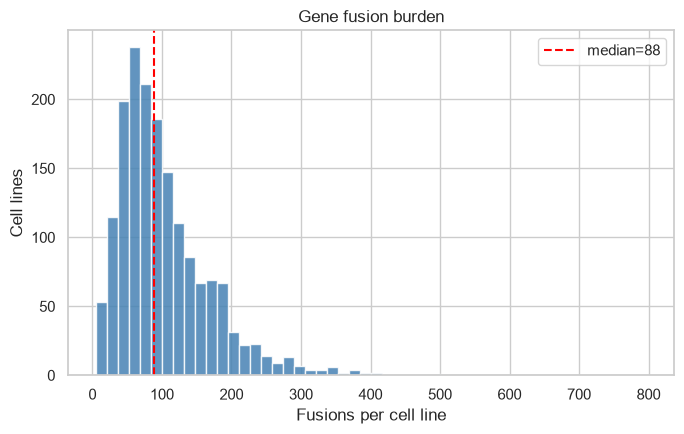

In [3]:
fusions_per_model = df_def.groupby('ModelID').size()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(fusions_per_model, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(fusions_per_model.median(), color='red', linestyle='--', label=f"median={fusions_per_model.median():.0f}")
ax.set_xlabel('Fusions per cell line'); ax.set_ylabel('Cell lines')
ax.set_title('Gene fusion burden'); ax.legend()
plt.tight_layout(); plt.show()

### Why this EDA check matters

Most lines carry a handful of fusions; a long right tail of very high burden usually signals
genomic instability rather than one dominant driver event — that distinction matters when scoring
an exclusion gene against fusion evidence, since a hypermutated line's fusion count is not itself
evidence of a specific driver.

## 3. Recurrent fusions vs. known oncogenic drivers

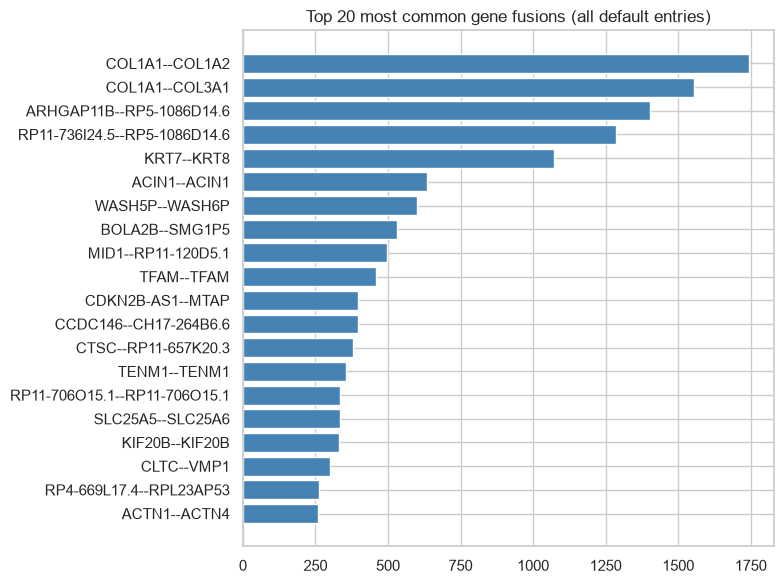

In [4]:
top_fusions = df_def['CanonicalFusionName'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_fusions.index[::-1], top_fusions.values[::-1], color='steelblue')
ax.set_title('Top 20 most common gene fusions (all default entries)')
plt.tight_layout(); plt.show()

**Caveat before reading the chart above:** the *most frequent* fusions are typically recurrent
read-through or splicing artefacts (e.g. adjacent collagen or keratin genes), not clinical drivers —
frequency alone does not mean biological importance. Checking known driver fusions directly is the
correct test:

In [5]:
lineage = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv', usecols=['DepMap_ID', 'lineage']).set_index('DepMap_ID')['lineage']
known_drivers = ['BCR--ABL1', 'EML4--ALK', 'TMPRSS2--ERG', 'EWSR1--FLI1', 'FGFR3--TACC3',
                  'PML--RARA', 'ETV6--RUNX1', 'CBFB--MYH11']
rows = []
for k in known_drivers:
    sub = df_def[df_def['CanonicalFusionName'].str.contains(k, na=False, regex=False)].drop_duplicates('ModelID')
    if len(sub):
        top_lineage = sub.assign(lin=sub['ModelID'].map(lineage))['lin'].value_counts()
        rows.append((k, len(sub), top_lineage.index[0] if len(top_lineage) else 'NA'))
    else:
        rows.append((k, 0, 'not called in this filtered set'))
pd.DataFrame(rows, columns=['known driver fusion', 'cell lines carrying it', 'top lineage'])

,known driver fusion,cell lines carrying it,top lineage
0,BCR--ABL1,0,not called in this filtered set
1,EML4--ALK,0,not called in this filtered set
2,TMPRSS2--ERG,0,not called in this filtered set
3,EWSR1--FLI1,20,bone
4,FGFR3--TACC3,7,urinary_tract
5,PML--RARA,1,blood
6,ETV6--RUNX1,1,blood
7,CBFB--MYH11,1,blood


### Why this EDA check matters

This is the biological validity check for the layer: known driver fusions should be rare overall
but concentrated in their textbook lineage (e.g. `BCR--ABL1` in blood/leukaemia lines). A driver
fusion that is entirely absent from this filtered call set is a **coverage caveat to disclose**, not
evidence the fusion doesn't occur — this dataset only captures what its calling pipeline detected.

## 4. Confidence, structural type, and reading frame

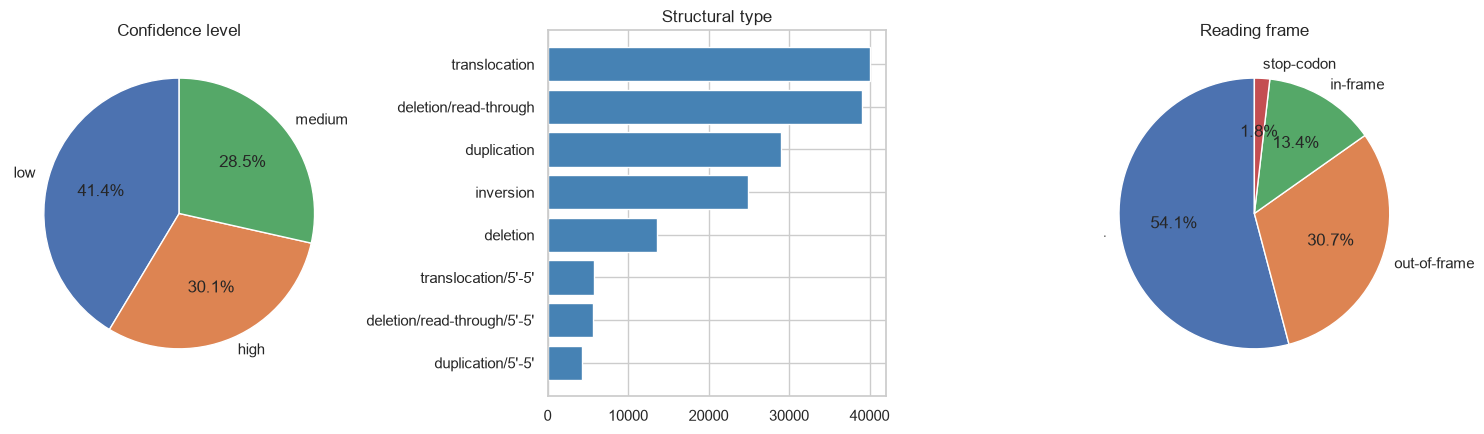

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
conf = df_def['confidence'].value_counts()
axes[0].pie(conf.values, labels=conf.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Confidence level')

ftype = df_def['type'].value_counts().head(8)
axes[1].barh(ftype.index[::-1], ftype.values[::-1], color='steelblue')
axes[1].set_title('Structural type')

rf = df_def['reading_frame'].value_counts()
axes[2].pie(rf.values, labels=rf.index, autopct='%1.1f%%', startangle=90)
axes[2].set_title('Reading frame')
plt.tight_layout(); plt.show()

### Why this EDA check matters

Only high-confidence, in-frame fusions are strong candidates for producing a functional fusion
protein — a low-confidence or out-of-frame call is weaker evidence and should carry a lower
desirability weight or a caveat when the scorer treats fusion as a scored layer, not be counted
identically to a high-confidence in-frame BCR-ABL1-style call.

## 5. Identity join path to the primary spine

In [7]:
df9 = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv', usecols=['DepMap_ID', 'lineage'])
fusion_models = set(df_def['ModelID'].dropna())
spine_models = set(df9['DepMap_ID'].dropna())
matched = fusion_models & spine_models

print(f"Cell lines with fusion calls (this table) : {len(fusion_models)}")
print(f"Reach primary spine (file 9)               : {len(matched)} ({len(matched)/len(fusion_models):.1%})")
print(f"Primary spine with NO fusion assay          : {len(spine_models - fusion_models)} of {len(spine_models)} ({(len(spine_models)-len(matched))/len(spine_models):.1%})")

Cell lines with fusion calls (this table) : 1699
Reach primary spine (file 9)               : 1428 (84.0%)
Primary spine with NO fusion assay          : 412 of 1840 (22.4%)


### Why this EDA check matters

`ModelID` is a direct key here, so the join itself is clean; the real constraint is coverage — most
of the primary spine was never fusion-assayed at all, which is exactly why `not_assayed` must render
as "fusion status unknown" rather than "no fusion detected.

## 6. Coverage bias by lineage

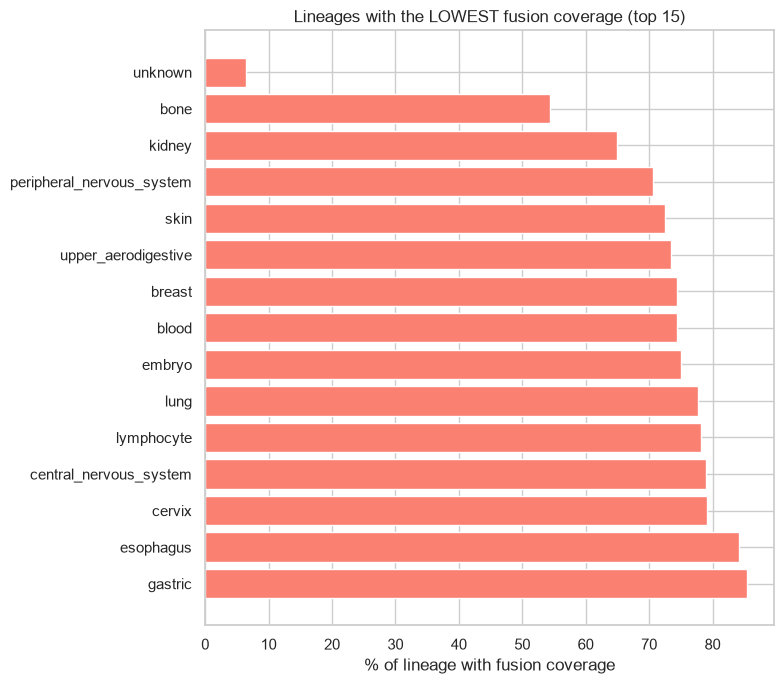

In [8]:
covered = df9[df9['DepMap_ID'].isin(matched)]
total_per_lineage = df9['lineage'].value_counts()
covered_per_lineage = covered['lineage'].value_counts()
coverage_pct = (covered_per_lineage / total_per_lineage * 100).dropna().sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
bottom15 = coverage_pct.head(15)
ax.barh(bottom15.index[::-1], bottom15.values[::-1], color='salmon')
ax.set_xlabel('% of lineage with fusion coverage')
ax.set_title('Lineages with the LOWEST fusion coverage (top 15)')
plt.tight_layout(); plt.show()

### Why this EDA check matters

A researcher excluding a gene on fusion evidence in a poorly-covered lineage is at the highest risk
of a false "no fusion" read that is really "never checked" — this chart identifies exactly which
lineages need the strongest missing-evidence caveat.

## Decisions carried into the next notebooks

1. **Filter to `IsDefaultEntryForModel == 'Yes'` before any per-line aggregation.**
2. **Fusion frequency is not the same as fusion importance** — known drivers must be checked by
   name, not read off the "most common" chart (§3).
3. `not_assayed` for this layer renders as **"fusion status unknown"**, never "no fusion" — coverage
   is real and lineage-biased (§5–6).
4. Confidence and reading-frame should modulate how strongly a fusion call is weighted once fusion
   enters the score (§4) — a low-confidence, out-of-frame call is weaker evidence.
5. **Limitation:** the known-driver check in §3 uses a small curated list and a substring match on
   `CanonicalFusionName`; it is a spot check, not a systematic driver-fusion catalogue lookup.